# realworld.ipynb

In [7]:
%matplotlib widget
import matplotlib.pyplot as plt
import roadside as rs
import efd_find_cuts as efd
import os
import pandas as pd
import sqlite3
# from dataclasses import dataclass
import numpy as np
import cv2
from icecream import ic
from shapely.geometry import Polygon
from shapely.wkt import loads

from pyefd import elliptic_fourier_descriptors, reconstruct_contour


# This package is in the working directory at efd_alignment.py
# from efd_alignment import reconstruct_aligned_mask

# Functions

In [8]:
def reconstruct_aligned_mask(image_shape, contour, order=10, align_to_centroid=True):
    """
    Finds EFDs and reconstructs the mask perfectly aligned with the original locus.
    
    Parameters:
        image_shape (tuple): Shape of the original image (H, W)
        contour (ndarray): Contour array of original image; shape (N, 2) or (N, 1, 2)
        order (int): Number of Fourier coefficients to use
        
    Returns:
        ndarray: Binary mask with the reconstructed shape in the correct position
    """
    
    ic()
    
    # 1. Standardize contour shape to (N, 2)
    contour = contour.reshape(-1, 2)
    
    # 2. Calculate the true centroid (locus) of the original contour using moments.
    # This keeps the reconstructed shape strictly bound to the true defect location.
    M = cv2.moments(contour)
    if M["m00"] != 0:
        cX = M["m10"] / M["m00"]
        cY = M["m01"] / M["m00"]
    else:
        cX, cY = np.mean(contour, axis=0)

    # 3. Compute EFD coefficients (keeping unnormalized to retain spatial properties)
    coeffs = elliptic_fourier_descriptors(contour, order=order, normalize=False)
    
    # 4. Corrected function: Reconstruct contour points via the native API.
    # We pass the calculated cX, cY into the locus argument.
    # Next line added by Aubrey Moore 2026-06-02
    num_points = contour.shape[0]  # Use the original number of contour points for reconstruction
    reconstructed_points = reconstruct_contour(coeffs, locus=(cX, cY), num_points=num_points)
    
    # 5. Prevent sub-pixel "floor bias" shift by rounding before converting to integer
    reconstructed_contour = np.round(reconstructed_points).astype(np.int32)
    reconstructed_contour = reconstructed_contour.reshape(-1, 1, 2)
    
    # 6. Create the aligned mask
    reconstructed_mask = np.zeros(image_shape, dtype=np.uint8)
    cv2.drawContours(reconstructed_mask, [reconstructed_contour], -1, 255, -1)
    
    if align_to_centroid:
        # Calculate the centroid of the reconstructed mask
        M_recon = cv2.moments(reconstructed_contour)
        if M_recon["m00"] != 0:
            recon_cX = M_recon["m10"] / M_recon["m00"]
            recon_cY = M_recon["m01"] / M_recon["m00"]
        else:
            recon_cX, recon_cY = np.mean(reconstructed_contour.reshape(-1, 2), axis=0)
        
        # Calculate the shift needed to align the reconstructed contour's centroid with the original
        shift_x = int(cX - recon_cX)
        shift_y = int(cY - recon_cY)
        ic(shift_x, shift_y)
        
        # Shift the reconstructed contour and mask
        translation_matrix = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        reconstructed_mask = cv2.warpAffine(reconstructed_mask, translation_matrix, (image_shape[1], image_shape[0]))
        reconstructed_contour = cv2.transform(reconstructed_contour, translation_matrix)
    
    return reconstructed_contour, reconstructed_mask


In [9]:
def get_filtered_contours(tree_contour, tree_mask, min_area=50):
    """ 
    Returns contours of the reconstructed mask that are not present in the original tree mask, filtered by a minimum area threshold (pixel count).
    """
    efd_results = efd.efd_find_cuts(tree_contour, tree_mask, order=80)
    recon_mask = efd_results.reconstructed_mask
    
    additions_mask = cv2.bitwise_and(recon_mask, cv2.bitwise_not(tree_mask))
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(3, 3))
    opened_mask = cv2.morphologyEx(additions_mask, cv2.MORPH_OPEN, kernel, iterations=1)    
    opened_contours, _ = cv2.findContours(opened_mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    
    filtered_contours = []
    for cnt in opened_contours:
        # Calculate moments
        M = cv2.moments(cnt)
        if M["m00"] >= min_area:
            filtered_contours.append(cnt)
            
    return filtered_contours

In [10]:
def get_damage_data(df_detections, min_area=50):
    results = []
    damage_id = 1
    for row in df_detections.itertuples():
        tree_contour = rs.wkt2contour(row.tree_wkt).squeeze()
        canvas = np.zeros((row.image_height, row.image_width), dtype="uint8")
        tree_mask = cv2.fillPoly(canvas, [tree_contour], 1)    
        damage_contours = get_filtered_contours(tree_contour, tree_mask, min_area=min_area)
        for damage_contour in damage_contours:
            
            # convert damage_contour to WKT
            polygon = Polygon(np.squeeze(damage_contour))
            damage_wkt = polygon.wkt
            
            mydict = {
                'image_id': row.image_id,
                'detection_id': row.detection_id, 
                'damage_id': damage_id, 
                'damage_wkt': damage_wkt}
            damage_id += 1 
            results.append(mydict)      
    return pd.DataFrame(results)

# df_damage = get_damage_data(df_detections)
# df_damage

# Main

In [11]:
# If it does not already exist, build a database (test.db) containing data from 2 example images.
# The example images will be downloaded to the data_cache directory and SAM3 will
# detect and segment coconut palms.

ic.disable()
if os.path.exists('test.db'):
    pass
else:
    rs.test_build_db()
ic.enable()

SHA256 hash of downloaded file: bb2223e68e5eabcb85fef2a89237cdb99b9f613151bcecb5bdba7b663ddbfedb
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


KeyError: 'db_path'

In [ ]:
# get the data we need from the database
sql = ''' 
SELECT images.image_id, detection_id, image_path, image_width, image_height, tree_wkt
FROM images, detections
WHERE images.image_id=detections.image_id
'''
df_detections = pd.read_sql(sql, sqlite3.connect('test.db'))
df_detections.head()

DatabaseError: Execution failed on sql ' 
SELECT images.image_id, detection_id, image_path, image_width, image_height, tree_wkt
FROM images, detections
WHERE images.image_id=detections.image_id
': no such table: detections

In [ ]:
# Add damage table to database
df_damage = get_damage_data(df_detections=df_detections)

# add damage table to database
df_damage.to_sql(
    name="damage",     # Name of the new SQL table
    con=sqlite3.connect("test.db"),
    if_exists="replace",  # Stops execution if the table already exists
    index=False,       # Excludes the DataFrame index from becoming a column
)

# test by reading back from database
df_damage = pd.read_sql('SELECT * FROM damage', sqlite3.connect('test.db'))
df_damage

,image_id,detection_id,damage_id,damage_wkt
0,1,1,1,"POLYGON ((489 612, 488 613, 488 614, 487 615, ..."
1,1,2,2,"POLYGON ((1022 1215, 1021 1216, 1021 1217, 102..."
2,2,3,3,"POLYGON ((1151 231, 1150 232, 1149 232, 1148 2..."
3,2,4,4,"POLYGON ((1679 717, 1678 718, 1678 719, 1677 7..."
4,2,5,5,"POLYGON ((997 825, 996 826, 996 827, 996 828, ..."
5,2,6,6,"POLYGON ((911 819, 910 820, 909 820, 909 821, ..."
6,2,6,7,"POLYGON ((876 784, 875 785, 874 785, 873 786, ..."
7,2,7,8,"POLYGON ((560 273, 560 274, 560 275, 561 276, ..."
8,2,8,9,"POLYGON ((1151 865, 1150 866, 1149 867, 1148 8..."
9,2,8,10,"POLYGON ((1143 675, 1142 676, 1141 676, 1140 6..."


# CLEAN CODE

In [ ]:
def register_by_phase_correlation(mask_static, mask_moving):
    """   
    Reference: https://gemini.google.com/share/cd713927348a
    
    The original code was written by Gemini (see reference).
    From visualizing results, I suspected that there is an error in 
    calculating the translation matrix as noted below.    
    """
    # Convert masks to float32
    static_f = np.float32(mask_static)
    moving_f = np.float32(mask_moving)
    
    # Perform phase correlation to find the shift
    # Returns (shift_x, shift_y) and the response peak quality
    (tx, ty), response = cv2.phaseCorrelate(static_f, moving_f)
    
    # Create the translation matrix using the detected shifts
    # ORIGINAL CODE IN LINE BELOW MAY BE WRONG
    # T = np.float32([[1, 0, tx], [0, 1, ty]])
    # Following line added by Aubrey Moore
    T = np.float32([[1, 0, tx], [0, 1, -ty]])
    
    # Warp the moving mask to match the static mask
    rows, cols = mask_static.shape[:2]
    registered_mask = cv2.warpAffine(mask_moving, T, (cols, rows))
    
    # Following 2 lines added by Aubrey Moore
    # Threshold so that values are 0 or 255
    cv2.threshold(registered_mask, 124, 255, cv2.THRESH_BINARY, registered_mask)
    
    return registered_mask, (tx, ty)

In [ ]:
def get_centroid(contour):
    """ Returns centroid of a contour. """
    M = cv2.moments(contour)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = np.mean(contour, axis=0)
    return cX, cY    

In [ ]:
def shift_mask_upwards(mask, N):
    """ Shifts a binary mask upwards by N pixels and returns the new mask"""
    shifted_mask = np.zeros_like(mask)
    shifted_mask[:-N, :] = mask[N:, :]
    return shifted_mask

In [ ]:
con = sqlite3.connect('test.db')

image_id = 1

sql = f'select image_path from images where image_id={image_id}'
for row in con.execute(sql):
    image_path = row[0]
    ic(image_path)

sql = f'select tree_wkt from detections where image_id = {image_id}'
tree_contours = []
for row in con.execute(sql):
    tree_wkt = row[0]
    poly = loads(tree_wkt)
    coords = list(poly.exterior.coords)    
    contour = np.array(coords, dtype=np.int32).reshape(-1, 1, 2)
    tree_contours.append(contour)
    
con.close()

ic| image_path: 'data_cache/example_images/08hs-palms-03-zglw-superJumbo.webp'


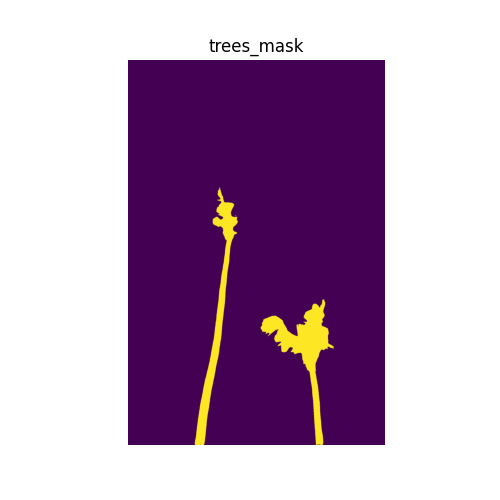

In [ ]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Create trees_mask - a binary mask of all trees in an image
canvas = np.zeros(img.shape[:2], np.uint8)
trees_mask = cv2.drawContours(canvas, tree_contours, -1, 255, -1)

plt.figure(figsize=(5, 5))
plt.imshow(trees_mask)
plt.title('trees_mask')
plt.axis("off")  # Removes default graph grid tick measurements
plt.show()

In [ ]:
def create_overlaid_image(img, mask, color=(255,255,0), alpha=0.7):

    # 2. Create a colored image of the same size (e.g., solid Red overlay)
    # In OpenCV, color format is BGR: (Blue, Green, Red)
    overlay_color = np.zeros_like(img)
    overlay_color[:] = (0, 0, 255)  # Change this tuple to get different colors

    # 3. Apply the binary mask to isolate the color to the mask region
    # Wherever the mask is 0 (black), the colored overlay becomes 0 (black)
    colored_mask = cv2.bitwise_and(overlay_color, overlay_color, mask=mask)

    # 4. Blend the images together
    # alpha: weight of original image, beta: opacity of the mask, gamma: scalar offset
    beta = 1.0 - alpha
    output = cv2.addWeighted(img, alpha, colored_mask, beta, 0)
    
    return output

In [ ]:
def apply_transparency_mask(image, mask, output_path, semi_transparent_value=128):
    """
    Applies a binary mask to a color image, making mask 0 transparent 
    and mask 255 semitransparent.
    """
    # Load images
    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Create alpha channel based on mask rules
    alpha = np.zeros_like(mask)
    alpha[mask == 255] = semi_transparent_value
    
    # Merge BGR channels with the new alpha channel
    b, g, r = cv2.split(image)
    transparent_image = cv2.merge([b, g, r, alpha])
    
    # Save output (

# Example usage:
# apply_transparency_mask('color.jpg', 'mask.png', 'output.png', semi_transparent_value=128)


ic| 3337628227.py:14 in reconstruct_aligned_mask() at 11:07:38.050
ic| shift_x: 3, shift_y: -41


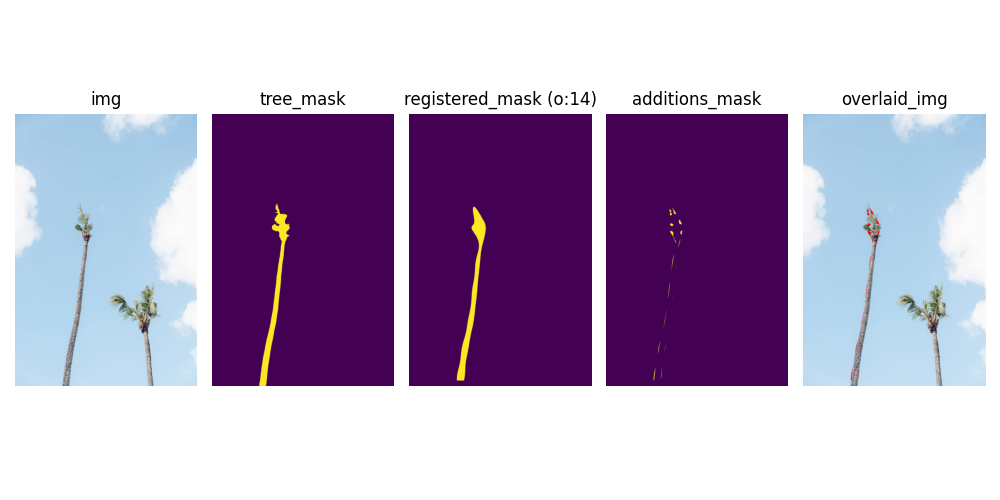

ic| 3337628227.py:14 in reconstruct_aligned_mask() at 11:07:38.973
ic| shift_x: 0, shift_y: 41


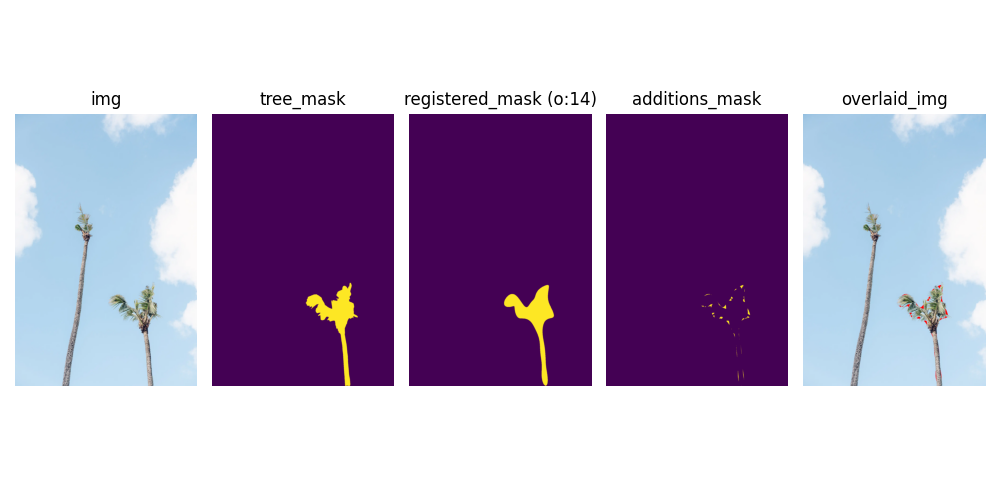

In [ ]:
order = 14

for tree_contour in tree_contours:
    canvas = np.zeros(img.shape[:2], np.uint8)
    tree_mask = cv2.drawContours(canvas, [tree_contour], -1, 255, -1)
    tree_mask_cx, tree_mask_cy = get_centroid(tree_mask)
    
    _, reconstructed_mask = reconstruct_aligned_mask(image_shape=img.shape[:2], contour=tree_contour, order=order)
    reconstructed_mask_cx, reconstructed_mask_cy = get_centroid(reconstructed_mask)
    
    # ic(tree_mask_cx, tree_mask_cy)
    # ic(reconstructed_mask_cx, reconstructed_mask_cy)
    
    # shifted_reconstructed_mask = shift_mask_upwards(mask=reconstructed_mask, N=reconstructed_mask_cy - tree_mask_cy)
    
    # registered_mask, (tx, ty) = register_by_phase_correlation(mask_static=tree_mask, mask_moving=reconstructed_mask)
    # ic(tx, ty)
    registered_mask = reconstructed_mask.copy()
    
    # 3. Additions: Pixels missing in tree_mask, present in reconstructed_mask
    
    additions_mask = cv2.bitwise_and(registered_mask, cv2.bitwise_not(tree_mask))
    
    # create overlaid_image
    deformity_pixels = (additions_mask == 255)
    overlaid_img = img.copy()
    overlaid_img[deformity_pixels] = [255, 0, 0]
    
    # visualization
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(10,5), sharex=True, sharey=True)
    
    ax1.imshow(img)
    ax1.set_title('img')
    ax1.axis('off')
    
    ax2.imshow(tree_mask)
    ax2.set_title('tree_mask')
    ax2.axis('off')
    
    ax3.imshow(registered_mask)
    ax3.set_title(f'registered_mask (o:{order})')
    ax3.axis('off')
    
    ax4.imshow(additions_mask)
    ax4.set_title('additions_mask')
    ax4.axis('off')
    
    ax5.imshow(overlaid_img)
    ax5.set_title('overlaid_img')
    ax5.axis('off')

    plt.tight_layout()
    plt.show()